# PropPulse — Exploratory Data Analysis (01)

**Scope:** processed **train** split only (`data/processed/train.csv`, 945 rows,
YrSold ≤ 2008). `val.csv` is used **only** in the seasonality section to extend
the yearly view to 2009. **`test.csv` (2010) is sealed and never touched.**

Conventions (SPEC §14 / DECISIONS.md):

- Processed CSVs store absent features as the literal string `"None"` and contain
  **zero NaNs** → always read with `pd.read_csv(..., keep_default_na=False)`.
- `lat`/`long` are **approximate neighborhood centroids** (ADR-2) — geographic
  resolution is the neighborhood, not the street.
- `days_on_market` / `sells_within_30_days` are a **SIMULATED TARGET** (ADR-3) —
  any fast-sale patterns describe the simulation, not the real Ames market.
- `price_per_sqft` is derived from `SalePrice` → **EDA-only**, never a model
  feature (leakage rule, SPEC §5).


In [1]:
"""Setup: imports, repo paths, data loading, EDA-only derived columns."""
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

# Make the repo importable regardless of the notebook's working directory.
_CWD = Path.cwd().resolve()
_REPO = _CWD.parent if _CWD.name == "notebooks" else _CWD
if str(_REPO) not in sys.path:
    sys.path.insert(0, str(_REPO))

from ml.paths import (  # noqa: E402
    EXTERNAL_DIR,
    FIGURES_DIR,
    PROCESSED_DIR,
    RAW_AMES_DIR,
    REPO_ROOT,
    RANDOM_SEED,
)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

DPI: int = 150


def save_fig(fig: plt.Figure, name: str) -> Path:
    """Save *fig* to the repo-level ``figures/`` directory and return the path."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"saved -> {path.relative_to(REPO_ROOT)}")
    return path


def haversine_km(lat1: np.ndarray, lon1: np.ndarray, lat2: float, lon2: float) -> np.ndarray:
    """Great-circle distance in km between points (lat1, lon1) and (lat2, lon2)."""
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = np.radians(lat2 - lat1)
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dl / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


train = pd.read_csv(PROCESSED_DIR / "train.csv", keep_default_na=False)
assert train.isna().sum().sum() == 0, "processed train must contain zero NaNs"

# --- EDA-only derived columns (mirror SPEC §5 formulas; never model inputs here) ---
train["price_per_sqft"] = train["SalePrice"] / train["GrLivArea"]
train["total_bath"] = (
    train["FullBath"] + 0.5 * train["HalfBath"]
    + train["BsmtFullBath"] + 0.5 * train["BsmtHalfBath"]
)
train["property_age"] = train["YrSold"] - train["YearBuilt"]
train["log_sale_price"] = np.log1p(train["SalePrice"])

AMENITY_RULES: dict[str, pd.Series] = {
    "Fireplaces>0": train["Fireplaces"] > 0,
    "PoolArea>0": train["PoolArea"] > 0,
    "WoodDeckSF>0": train["WoodDeckSF"] > 0,
    "OpenPorchSF>0": train["OpenPorchSF"] > 0,
    "ScreenPorch>0": train["ScreenPorch"] > 0,
    "GarageCars>0": train["GarageCars"] > 0,
    "CentralAir=='Y'": train["CentralAir"] == "Y",
    "PavedDrive=='Y'": train["PavedDrive"] == "Y",
}
train["amenity_count"] = sum(AMENITY_RULES.values())

print(f"train shape: {train.shape}")
print(f"dtypes: {dict(train.dtypes.astype(str).value_counts())}")
print(f"NaN cells: {int(train.isna().sum().sum())} (convention: literal 'None' strings)")
print(f"splits years in train: {sorted(train['YrSold'].unique())}")


train shape: (945, 90)
dtypes: {'object': np.int64(43), 'int64': np.int64(39), 'float64': np.int64(8)}
NaN cells: 0 (convention: literal 'None' strings)
splits years in train: [np.int64(2006), np.int64(2007), np.int64(2008)]


## 1. Target distribution — `SalePrice` and `log1p(SalePrice)`

Per ADR-10 the regression target is trained as `log1p(SalePrice)` with RMSLE as
the primary metric. This section quantifies *why*: raw-price skewness vs the
log-transformed target.


SalePrice (train, n=945):
              mean: 182,125.1344
            median: 164,990.0000
               std: 78,872.4437
               min: 35,311
               max: 755,000
          skew_raw: 1.9673
      kurtosis_raw: 7.5529
        skew_log1p: 0.1746
    kurtosis_log1p: 0.8211


saved -> figures\01_saleprice_distribution.png


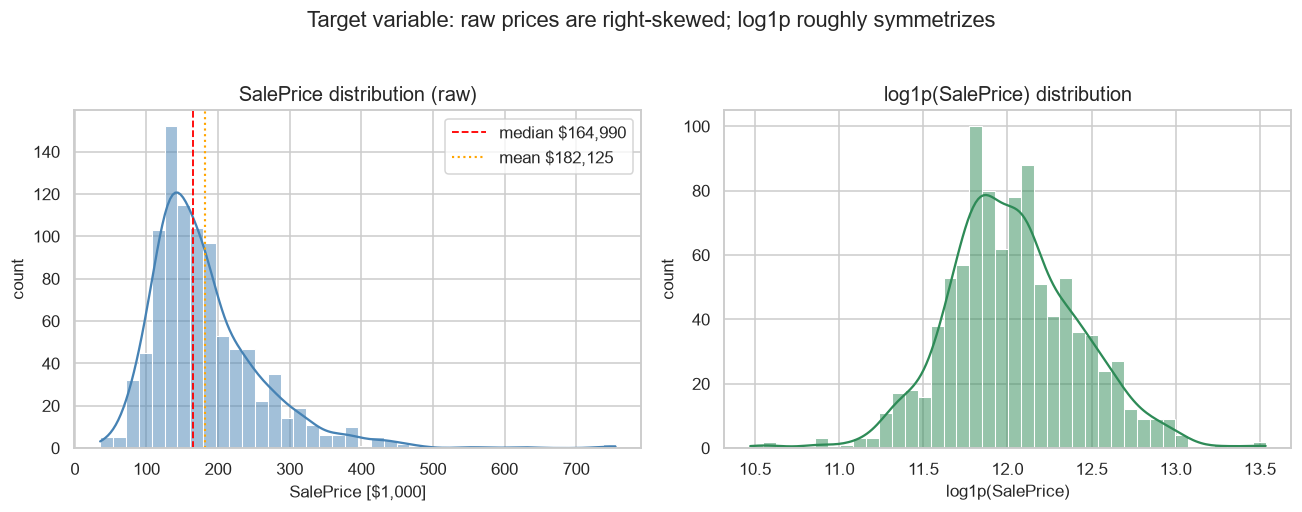

In [2]:
"""SalePrice distribution: raw vs log1p — figure 01."""
sp = train["SalePrice"]
stats = {
    "mean": sp.mean(), "median": sp.median(), "std": sp.std(),
    "min": sp.min(), "max": sp.max(),
    "skew_raw": sp.skew(), "kurtosis_raw": sp.kurtosis(),
    "skew_log1p": np.log1p(sp).skew(), "kurtosis_log1p": np.log1p(sp).kurtosis(),
}
print("SalePrice (train, n=%d):" % len(sp))
for k, v in stats.items():
    print(f"  {k:>16}: {v:,.4f}" if isinstance(v, float) else f"  {k:>16}: {v:,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(sp / 1000, bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(sp.median() / 1000, color="red", ls="--", lw=1.2, label=f"median ${sp.median():,.0f}")
axes[0].axvline(sp.mean() / 1000, color="orange", ls=":", lw=1.4, label=f"mean ${sp.mean():,.0f}")
axes[0].set(title="SalePrice distribution (raw)", xlabel="SalePrice [$1,000]", ylabel="count")
axes[0].legend()
sns.histplot(np.log1p(sp), bins=40, kde=True, ax=axes[1], color="seagreen")
axes[1].set(title="log1p(SalePrice) distribution", xlabel="log1p(SalePrice)", ylabel="count")
fig.suptitle("Target variable: raw prices are right-skewed; log1p roughly symmetrizes", y=1.03)
fig.tight_layout()
save_fig(fig, "01_saleprice_distribution.png")
plt.show()


**Interpretation.** The raw target is strongly right-skewed (skew ≈ 1.97,
excess kurtosis ≈ 7.6): a long tail of premium homes pulls the mean ($182k)
well above the median ($165k). After `log1p` the distribution is close to
symmetric (skew ≈ 0.17, kurtosis ≈ 0.8) — residuals in dollars scale with
price, so a log target matches the multiplicative error structure and keeps
luxury homes from dominating squared-error losses. This directly motivates
ADR-10 (train on `log1p`, report dollar metrics via `expm1`, RMSLE primary).


## 2. Price per square foot (EDA-only)

`price_per_sqft = SalePrice / GrLivArea`. It is **derived from the target**, so it
is a leakage feature and must never enter the regression/classification inputs
(SPEC §5) — it is used here (and later in clustering) only to compare market
segments on a size-normalized basis.


price_per_sqft [$ / sqft]:
  mean   : 121.13
  median : 120.58
  std    : 30.02
  min    : 30.37   max: 276.25
  skew   : 0.434


saved -> figures\02_price_per_sqft.png


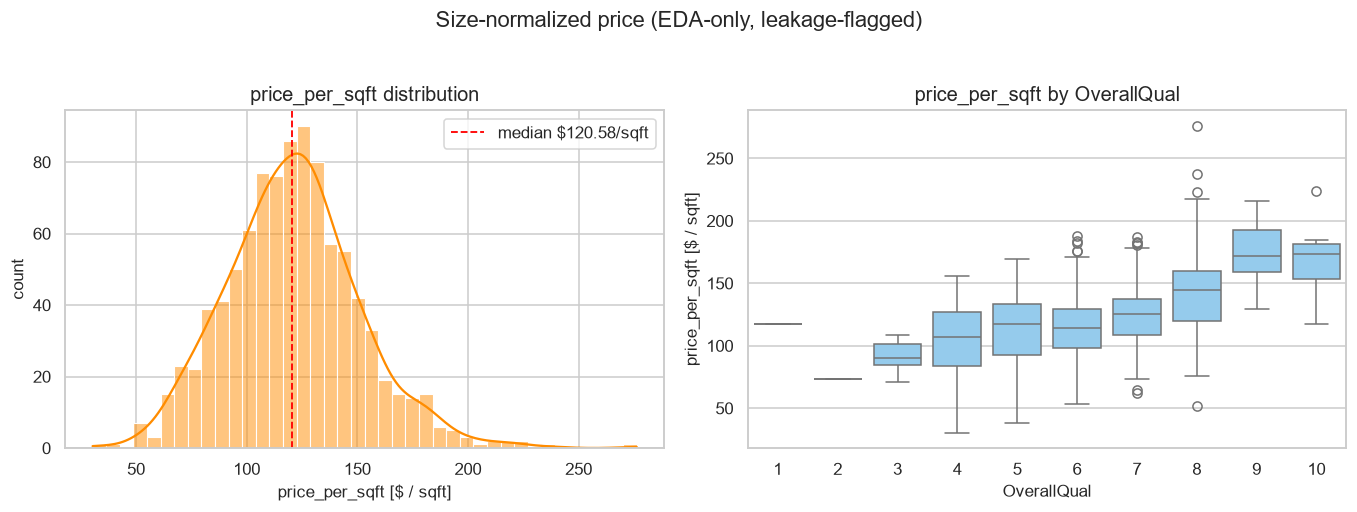

In [3]:
"""price_per_sqft distribution and its relation to build quality — figure 02."""
pps = train["price_per_sqft"]
print("price_per_sqft [$ / sqft]:")
print(f"  mean   : {pps.mean():,.2f}")
print(f"  median : {pps.median():,.2f}")
print(f"  std    : {pps.std():,.2f}")
print(f"  min    : {pps.min():,.2f}   max: {pps.max():,.2f}")
print(f"  skew   : {pps.skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
sns.histplot(pps, bins=40, kde=True, ax=axes[0], color="darkorange")
axes[0].axvline(pps.median(), color="red", ls="--", lw=1.2, label=f"median ${pps.median():,.2f}/sqft")
axes[0].set(title="price_per_sqft distribution", xlabel="price_per_sqft [$ / sqft]", ylabel="count")
axes[0].legend()
sns.boxplot(data=train, x="OverallQual", y="price_per_sqft", ax=axes[1], color="lightskyblue")
axes[1].set(title="price_per_sqft by OverallQual", xlabel="OverallQual", ylabel="price_per_sqft [$ / sqft]")
fig.suptitle("Size-normalized price (EDA-only, leakage-flagged)", y=1.03)
fig.tight_layout()
save_fig(fig, "02_price_per_sqft.png")
plt.show()


**Interpretation.** $/sqft is much tighter than raw price (roughly symmetric,
median close to mean) — most of the raw-price skew comes from *size*, not from
price level. The clear monotone rise of $/sqft with `OverallQual` shows quality
carries a per-area premium on top of size. For clustering (ADR-9), neighborhood
median $/sqft is a sensible size-free market descriptor.


## 3. Living area and lot area

`GrLivArea` (above-grade living sqft) and `LotArea` (lot sqft) — the two main
size drivers — against the target.


 GrLivArea: pearson r = 0.752 | spearman rho = 0.751 vs SalePrice
   LotArea: pearson r = 0.258 | spearman rho = 0.461 vs SalePrice
log1p(LotArea): pearson r = 0.388 vs SalePrice


saved -> figures\03_living_lot_area.png


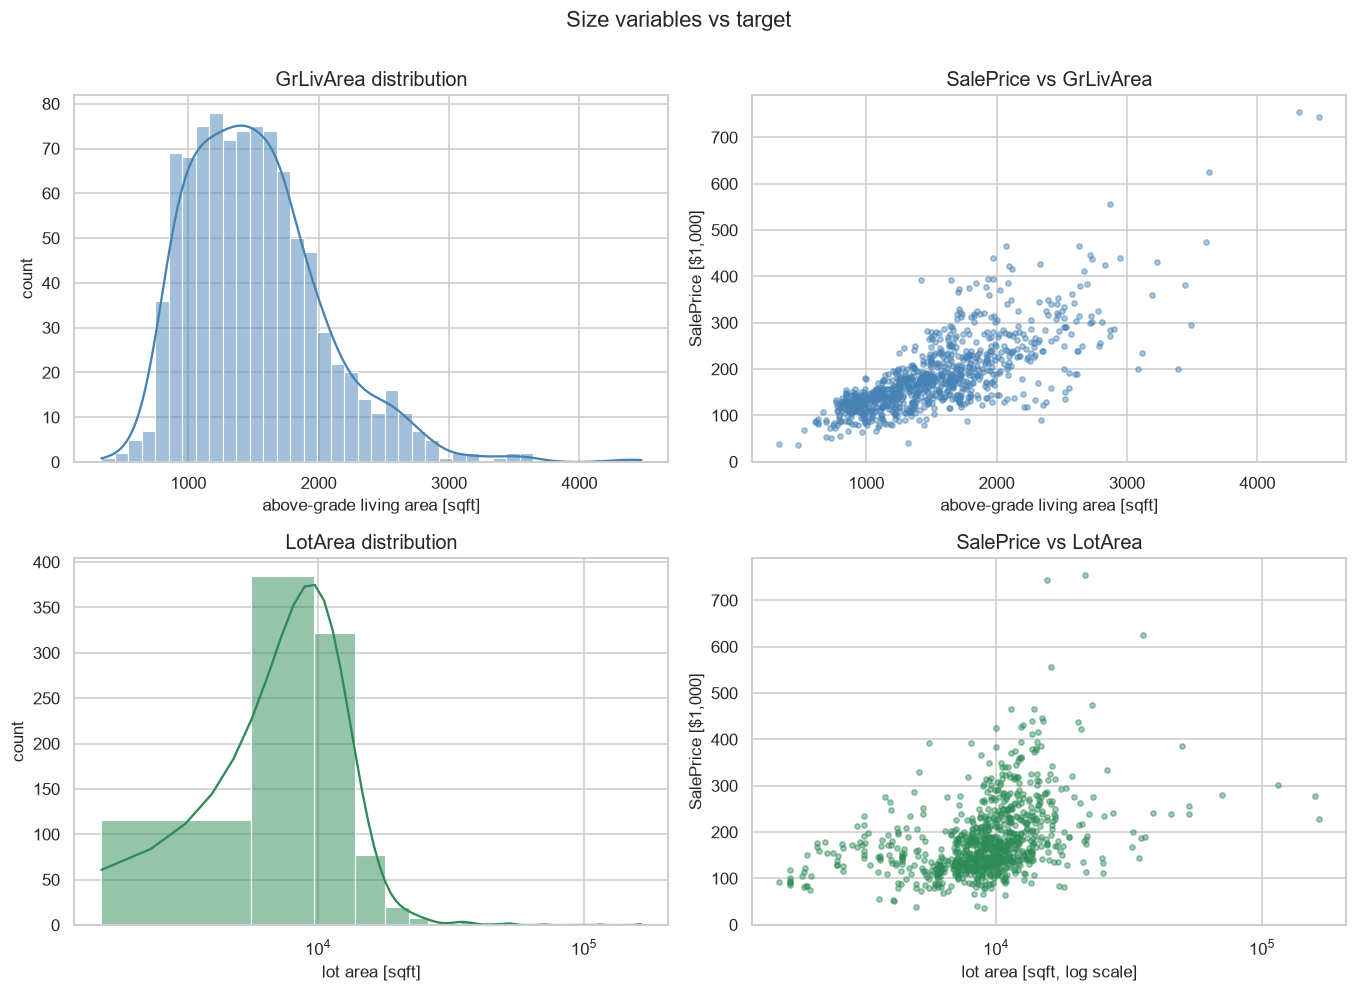

In [4]:
"""GrLivArea / LotArea vs SalePrice — figure 03."""
for col in ["GrLivArea", "LotArea"]:
    pear = train[[col, "SalePrice"]].corr(method="pearson").iloc[0, 1]
    spear = train[[col, "SalePrice"]].corr(method="spearman").iloc[0, 1]
    print(f"{col:>10}: pearson r = {pear:.3f} | spearman rho = {spear:.3f} vs SalePrice")
pear_loglot = train.assign(log_lot=np.log1p(train["LotArea"]))[["log_lot", "SalePrice"]].corr().iloc[0, 1]
print(f"{'log1p(LotArea)':>10}: pearson r = {pear_loglot:.3f} vs SalePrice")

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9))
sns.histplot(train["GrLivArea"], bins=40, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set(title="GrLivArea distribution", xlabel="above-grade living area [sqft]", ylabel="count")
axes[0, 1].scatter(train["GrLivArea"], train["SalePrice"] / 1000, s=12, alpha=0.45, color="steelblue")
axes[0, 1].set(title="SalePrice vs GrLivArea", xlabel="above-grade living area [sqft]", ylabel="SalePrice [$1,000]")
sns.histplot(train["LotArea"], bins=40, kde=True, ax=axes[1, 0], color="seagreen")
axes[1, 0].set(title="LotArea distribution", xlabel="lot area [sqft]", ylabel="count")
axes[1, 0].set_xscale("log")
axes[1, 1].scatter(train["LotArea"], train["SalePrice"] / 1000, s=12, alpha=0.45, color="seagreen")
axes[1, 1].set(title="SalePrice vs LotArea", xlabel="lot area [sqft, log scale]", ylabel="SalePrice [$1,000]")
axes[1, 1].set_xscale("log")
fig.suptitle("Size variables vs target", y=1.0)
fig.tight_layout()
save_fig(fig, "03_living_lot_area.png")
plt.show()


**Interpretation.** `GrLivArea` is one of the strongest single numeric
predictors and the relationship is visibly non-linear/variance-increasing —
exactly the pattern a log target and tree models handle well. `LotArea` is far
weaker and extremely skewed (a few huge lots); its log-transform correlates
better than the raw value, so linear models would want it transformed while
trees are indifferent. The visible fanning-out at large living areas again
argues for the log target.


## 4. Bedrooms and bathrooms

`BedroomAbvGr` as recorded; bathrooms aggregated as
`total_bath = FullBath + 0.5·HalfBath + BsmtFullBath + 0.5·BsmtHalfBath`
(SPEC §5 formula — includes basement halves).


BedroomAbvGr counts:
BedroomAbvGr
0      4
1     27
2    234
3    508
4    152
5     14
6      5
8      1

Median SalePrice by bedrooms:
BedroomAbvGr
0    215500.0
1    146000.0
2    140000.0
3    169495.0
4    197450.0
5    155700.0
6    135900.0
8    200000.0

total_bath range: 1.0 – 5.0, median 2.0
pearson r vs SalePrice: total_bath 0.636 | BedroomAbvGr 0.170


saved -> figures\04_bedrooms_bathrooms.png


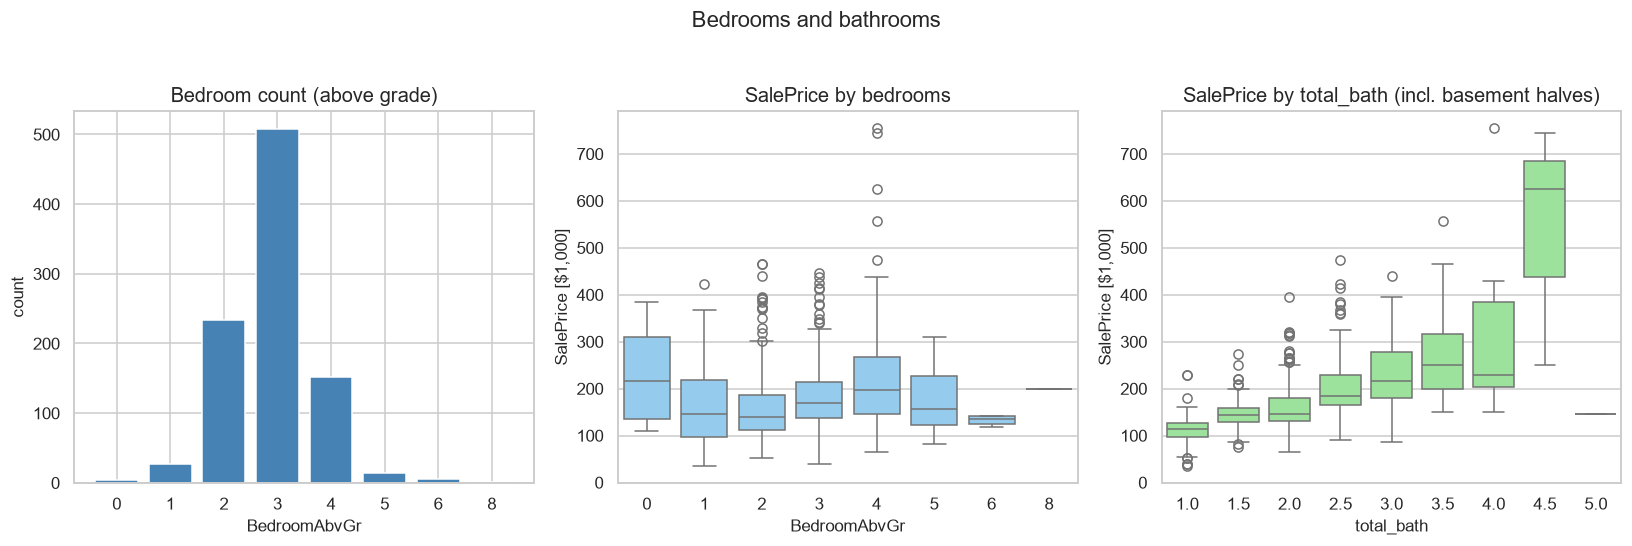

In [5]:
"""Bedroom/bathroom profiles and their price relation — figure 04."""
bed_counts = train["BedroomAbvGr"].value_counts().sort_index()
print("BedroomAbvGr counts:")
print(bed_counts.to_string())
med_price_bed = train.groupby("BedroomAbvGr")["SalePrice"].median()
print("\nMedian SalePrice by bedrooms:")
print(med_price_bed.round(0).to_string())
print(f"\ntotal_bath range: {train['total_bath'].min()} – {train['total_bath'].max()}, "
      f"median {train['total_bath'].median()}")
corr_bath = train[["total_bath", "SalePrice"]].corr().iloc[0, 1]
corr_bed = train[["BedroomAbvGr", "SalePrice"]].corr().iloc[0, 1]
print(f"pearson r vs SalePrice: total_bath {corr_bath:.3f} | BedroomAbvGr {corr_bed:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
axes[0].bar(bed_counts.index.astype(str), bed_counts.values, color="steelblue")
axes[0].set(title="Bedroom count (above grade)", xlabel="BedroomAbvGr", ylabel="count")
sns.boxplot(data=train, x="BedroomAbvGr", y=train["SalePrice"] / 1000, ax=axes[1], color="lightskyblue")
axes[1].set(title="SalePrice by bedrooms", xlabel="BedroomAbvGr", ylabel="SalePrice [$1,000]")
bath_order = sorted(train["total_bath"].unique())
sns.boxplot(data=train, x="total_bath", y=train["SalePrice"] / 1000, order=bath_order, ax=axes[2], color="lightgreen")
axes[2].set(title="SalePrice by total_bath (incl. basement halves)", xlabel="total_bath", ylabel="SalePrice [$1,000]")
fig.suptitle("Bedrooms and bathrooms", y=1.03)
fig.tight_layout()
save_fig(fig, "04_bedrooms_bathrooms.png")
plt.show()


**Interpretation.** 3-bedroom homes dominate the stock; the bedroom→price curve
rises to ~4 bedrooms then flattens/reverses for 5+ (small samples, and big old
houses with many small bedrooms are not premium). Bathrooms are the stronger
signal: median price rises monotonically with `total_bath`, which also beats
`BedroomAbvGr` on raw correlation. The engineered `total_bath` (with basement
halves at 0.5 weight) is justified — basement bathrooms clearly add value over
the above-grade count alone.


## 5. Property age

`property_age = YrSold - YearBuilt` (SPEC §5). New-build premium vs depreciation
of older stock.


property_age: min 0, median 35.0, max 136
pearson r vs SalePrice: -0.493

SalePrice by build decade:
           count    median
YearBuilt                 
1870           1  122000.0
1880           4  120750.0
1890           3  325000.0
1900          12  131000.0
1910          41  130000.0
1920          60  112500.0
1930          41  125500.0
1940          50  128000.0
1950         104  135875.0
1960         119  145000.0
1970         111  149900.0
1980          38  181450.0
1990         104  202500.0
2000         257  219500.0


saved -> figures\05_property_age.png


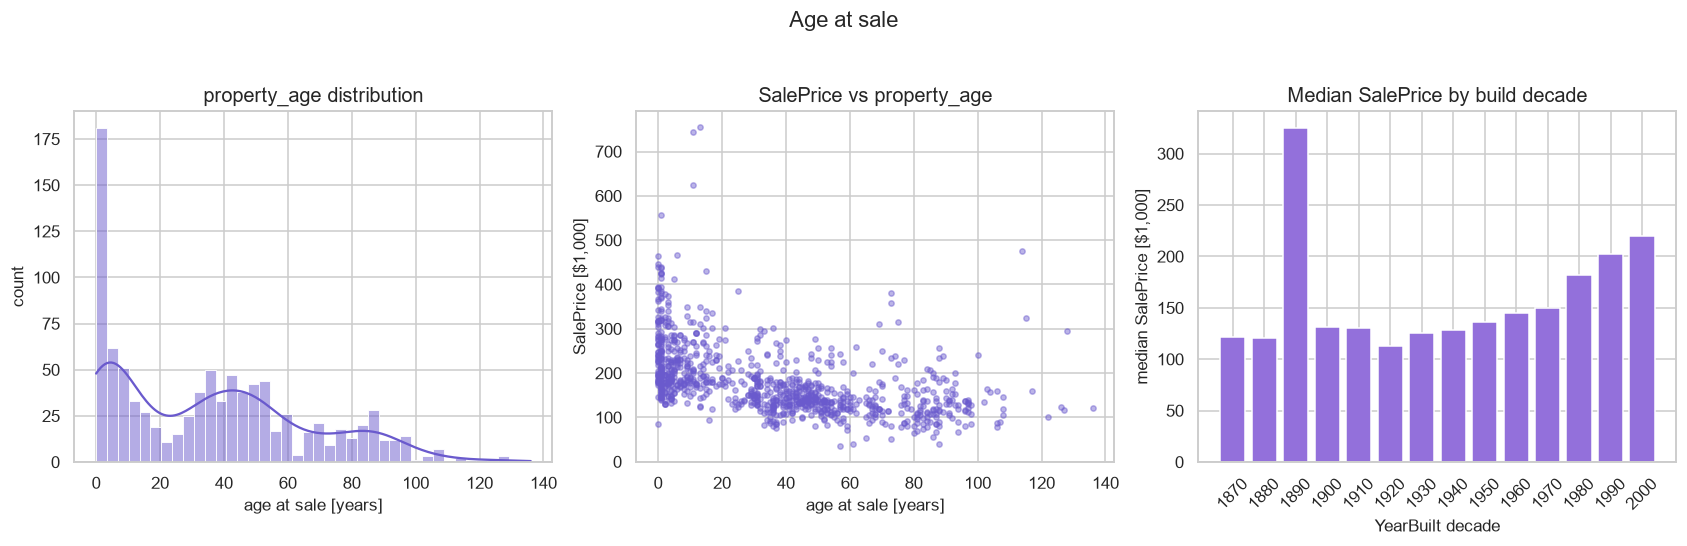

In [6]:
"""Property age profile and price relation — figure 05."""
age = train["property_age"]
print(f"property_age: min {age.min()}, median {age.median()}, max {age.max()}")
print(f"pearson r vs SalePrice: {train[['property_age', 'SalePrice']].corr().iloc[0, 1]:.3f}")
decade = (train["YearBuilt"] // 10 * 10).astype(int)
by_decade = train.groupby(decade)["SalePrice"].agg(["count", "median"])
print("\nSalePrice by build decade:")
print(by_decade.round(0).to_string())

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
sns.histplot(age, bins=40, kde=True, ax=axes[0], color="slateblue")
axes[0].set(title="property_age distribution", xlabel="age at sale [years]", ylabel="count")
axes[1].scatter(age, train["SalePrice"] / 1000, s=12, alpha=0.45, color="slateblue")
axes[1].set(title="SalePrice vs property_age", xlabel="age at sale [years]", ylabel="SalePrice [$1,000]")
axes[2].bar(by_decade.index.astype(str), by_decade["median"] / 1000, color="mediumpurple")
axes[2].set(title="Median SalePrice by build decade", xlabel="YearBuilt decade", ylabel="median SalePrice [$1,000]")
axes[2].tick_params(axis="x", rotation=45)
fig.suptitle("Age at sale", y=1.03)
fig.tight_layout()
save_fig(fig, "05_property_age.png")
plt.show()


**Interpretation.** The age distribution is spiky (building booms, e.g. the
2000s) rather than smooth. New homes command a large premium — the most recent
decades' medians sit far above pre-1950 stock — but the relationship is
non-monotone across the oldest decades (surviving pre-1930 homes are often
character properties), so a linear age term understates the effect; trees or a
binned/spline treatment capture it. `YearRemodAdd` (→ `years_since_remod`) is a
necessary complement: a renovated 1920s home does not price like an untouched one.


## 6. Overall quality and condition

`OverallQual` (1–10, materials/finish) and `OverallCond` (1–10, condition) —
ordinal but coded numeric.


SalePrice by OverallQual:
             count    median
OverallQual                 
1                1   39300.0
2                1   35311.0
3               11   87500.0
4               66  109454.0
5              263  134000.0
6              248  163000.0
7              206  197450.0
8              115  274000.0
9               24  343822.0
10              10  465750.0

SalePrice by OverallCond:
             count    median
OverallCond                 
2                2   77000.0
3               12   90500.0
4               36  120500.0
5              539  183000.0
6              161  145000.0
7              138  139200.0
8               44  150450.0
9               13  184000.0

pearson r vs SalePrice: OverallQual 0.789 | OverallCond -0.079


saved -> figures\06_quality_condition.png


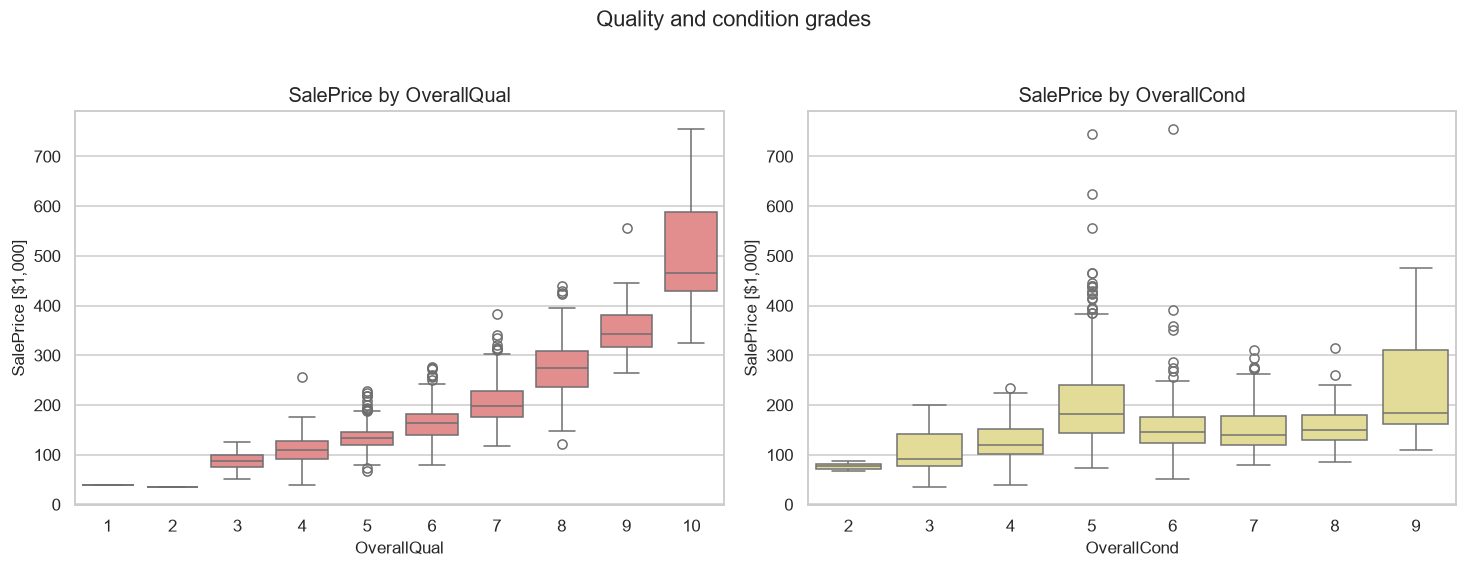

In [7]:
"""OverallQual / OverallCond vs SalePrice — figure 06."""
qual_tbl = train.groupby("OverallQual")["SalePrice"].agg(["count", "median"])
print("SalePrice by OverallQual:")
print(qual_tbl.round(0).to_string())
cond_tbl = train.groupby("OverallCond")["SalePrice"].agg(["count", "median"])
print("\nSalePrice by OverallCond:")
print(cond_tbl.round(0).to_string())
print(f"\npearson r vs SalePrice: OverallQual {train[['OverallQual', 'SalePrice']].corr().iloc[0, 1]:.3f} | "
      f"OverallCond {train[['OverallCond', 'SalePrice']].corr().iloc[0, 1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.boxplot(data=train, x="OverallQual", y=train["SalePrice"] / 1000, ax=axes[0], color="lightcoral")
axes[0].set(title="SalePrice by OverallQual", xlabel="OverallQual", ylabel="SalePrice [$1,000]")
sns.boxplot(data=train, x="OverallCond", y=train["SalePrice"] / 1000, ax=axes[1], color="khaki")
axes[1].set(title="SalePrice by OverallCond", xlabel="OverallCond", ylabel="SalePrice [$1,000]")
fig.suptitle("Quality and condition grades", y=1.03)
fig.tight_layout()
save_fig(fig, "06_quality_condition.png")
plt.show()


**Interpretation.** `OverallQual` is the single strongest feature: median price
rises steeply and roughly exponentially across grades (the jump from 7→10 is
larger in dollars than 1→4), which again favors a log target. `OverallCond` is
*not* monotone — the mass sits at grade 5, and grades 6–9 do not command higher
prices (partly confounded: newer expensive homes are rated 'average' condition
for their age). Expect quality to dominate importance rankings; condition adds
little on its own.


## 7. Amenity count

`amenity_count` = count of {Fireplaces>0, PoolArea>0, WoodDeckSF>0, OpenPorchSF>0,
ScreenPorch>0, GarageCars>0, CentralAir=='Y', PavedDrive=='Y'} (SPEC §5 formula).


SalePrice by amenity_count:
               count    median
amenity_count                 
0                  6   73750.0
1                 18  101500.0
2                 52  101600.0
3                150  126250.0
4                230  146500.0
5                240  179100.0
6                234  227500.0
7                 15  275000.0

amenity_count: min 0, max 7, median 5.0
pearson r vs SalePrice: 0.609

Amenity presence rates:
  Fireplaces>0    :  53.7%
  PoolArea>0      :   0.6%
  WoodDeckSF>0    :  46.6%
  OpenPorchSF>0   :  56.9%
  ScreenPorch>0   :   7.7%
  GarageCars>0    :  94.2%
  CentralAir=='Y' :  93.7%
  PavedDrive=='Y' :  91.2%


saved -> figures\07_amenity_count.png


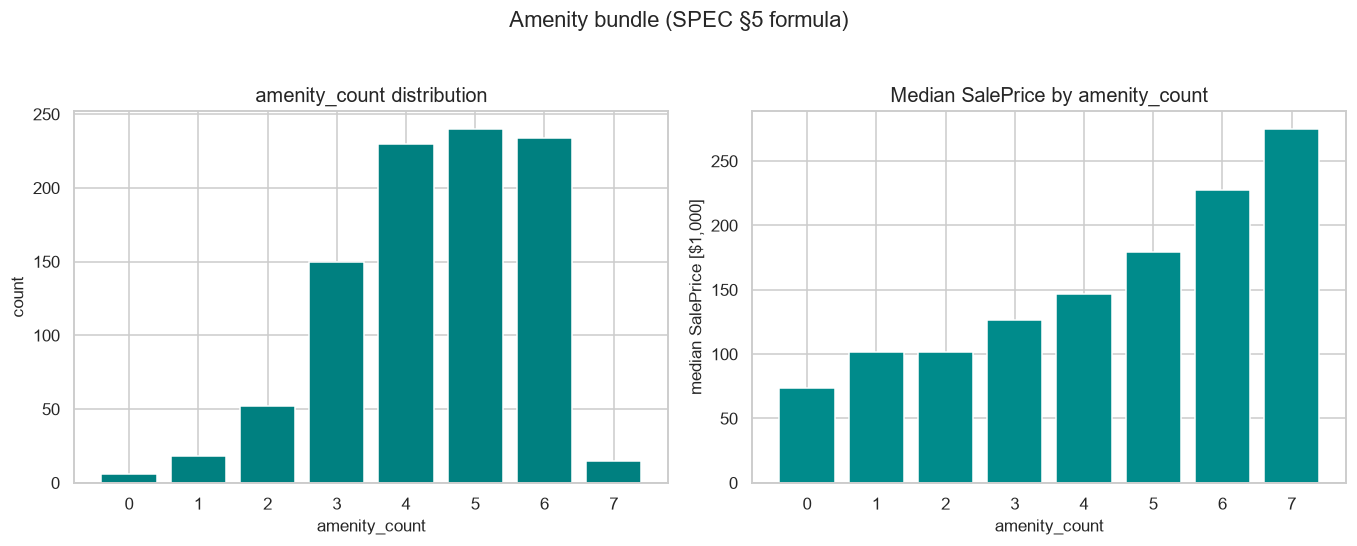

In [8]:
"""amenity_count distribution and price relation — figure 07."""
am = train.groupby("amenity_count")["SalePrice"].agg(["count", "median"])
print("SalePrice by amenity_count:")
print(am.round(0).to_string())
print(f"\namenity_count: min {train['amenity_count'].min()}, max {train['amenity_count'].max()}, "
      f"median {train['amenity_count'].median()}")
print(f"pearson r vs SalePrice: {train[['amenity_count', 'SalePrice']].corr().iloc[0, 1]:.3f}")
print("\nAmenity presence rates:")
for name, mask in AMENITY_RULES.items():
    print(f"  {name:<16}: {mask.mean() * 100:5.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
counts = train["amenity_count"].value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color="teal")
axes[0].set(title="amenity_count distribution", xlabel="amenity_count", ylabel="count")
axes[1].bar(am.index.astype(str), am["median"] / 1000, color="darkcyan")
axes[1].set(title="Median SalePrice by amenity_count", xlabel="amenity_count", ylabel="median SalePrice [$1,000]")
fig.suptitle("Amenity bundle (SPEC §5 formula)", y=1.03)
fig.tight_layout()
save_fig(fig, "07_amenity_count.png")
plt.show()


**Interpretation.** Nearly every home has a garage and paved drive, so those
indicators barely discriminate; the *count* still works because rarer amenities
(fireplaces, pools, porches, decks) stack on top. Median price rises smoothly
with amenity_count — a useful compact feature, though partially redundant with
`OverallQual` and size (they share variance; expect importance to be split
across them in tree models).


## 8. Geography

`lat`/`long` come from the **approximate neighborhood centroid lookup**
(ADR-2, `data/external/neighborhood_geo.csv`) — every property in a neighborhood
shares one point. A tiny seeded jitter is added *only for visualization* so
overlapping properties become visible. Downtown Ames reference: 42.0347, −93.6199.


distance to city center: min 0.50 km, max 5.79 km
pearson r(dist_center_km, SalePrice)   = 0.279
pearson r(dist_center_km, price_per_sqft) = 0.292


saved -> figures\08_geo_scatter.png


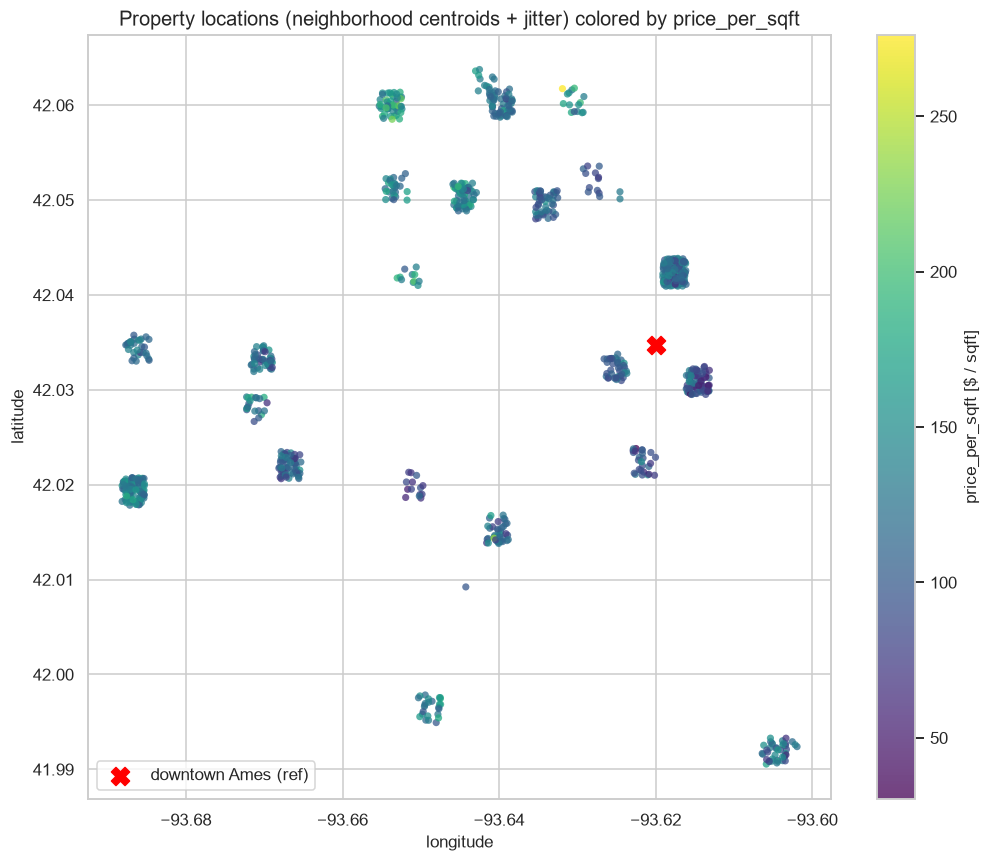

In [9]:
"""Geographic scatter colored by price_per_sqft — figure 08."""
rng = np.random.default_rng(RANDOM_SEED)
jitter = 0.0015  # ~150 m, visualization only
plot_df = train.assign(
    lat_j=train["lat"] + rng.uniform(-jitter, jitter, len(train)),
    long_j=train["long"] + rng.uniform(-jitter, jitter, len(train)),
)
train["dist_center_km"] = haversine_km(train["lat"].to_numpy(), train["long"].to_numpy(), 42.0347, -93.6199)
print(f"distance to city center: min {train['dist_center_km'].min():.2f} km, "
      f"max {train['dist_center_km'].max():.2f} km")
print(f"pearson r(dist_center_km, SalePrice)   = {train[['dist_center_km', 'SalePrice']].corr().iloc[0, 1]:.3f}")
print(f"pearson r(dist_center_km, price_per_sqft) = {train[['dist_center_km', 'price_per_sqft']].corr().iloc[0, 1]:.3f}")

fig, ax = plt.subplots(figsize=(9.5, 8))
sc = ax.scatter(plot_df["long_j"], plot_df["lat_j"], c=plot_df["price_per_sqft"],
                cmap="viridis", s=22, alpha=0.75, edgecolors="none")
ax.scatter([-93.6199], [42.0347], marker="X", s=140, color="red", label="downtown Ames (ref)", zorder=5)
cb = fig.colorbar(sc, ax=ax)
cb.set_label("price_per_sqft [$ / sqft]")
ax.set(title="Property locations (neighborhood centroids + jitter) colored by price_per_sqft",
       xlabel="longitude", ylabel="latitude")
ax.legend(loc="lower left")
fig.tight_layout()
save_fig(fig, "08_geo_scatter.png")
plt.show()


**Interpretation.** The expensive stock concentrates in the **north/northwest**
(Northridge Heights, Northridge, Stone Brook) and parts of the west, while the
southeast (Meadow Village, Mitchell) and central-old areas (Iowa DOT/RR,
Old Town, Edwards) are cheaper per sqft. Distance-to-center is only weakly
correlated with price (r ≈ +0.28, and the sign is *positive* — the premium
stock sits on the northern outskirts, not downtown). Location value is
**neighborhood identity**, not radial distance. That supports
neighborhood-level aggregates (SPEC §5 stats) and DBSCAN micro-markets (ADR-9)
over a smooth spatial model.


## 9. Neighborhood price differences

All 25 neighborhoods, boxplot sorted by median `SalePrice`.


                n  median_price  mean_price  median_ppsqft
Neighborhood                                              
NridgHt        47     318,000.0   314,413.4          153.0
NoRidge        26     295,750.0   351,020.8          129.5
StoneBr        15     286,000.0   304,547.1          153.9
Timber         25     239,000.0   240,644.1          133.6
Somerst        60     225,500.0   224,581.6          137.7
Veenker        11     218,000.0   238,772.7          143.8
Crawfor        39     217,000.0   211,011.8          113.7
ClearCr        20     205,750.0   214,246.6          121.5
CollgCr        98     198,250.0   199,452.8          132.0
Blmngtn        11     194,201.0   203,382.3          138.5
Gilbert        53     181,000.0   191,007.7          119.1
NWAmes         45     180,000.0   191,130.1          104.9
SawyerW        31     179,900.0   188,863.9          116.8
Blueste         1     151,000.0   151,000.0           97.0
Mitchel        32     146,900.0   150,226.6          132

saved -> figures\09_neighborhood_prices.png


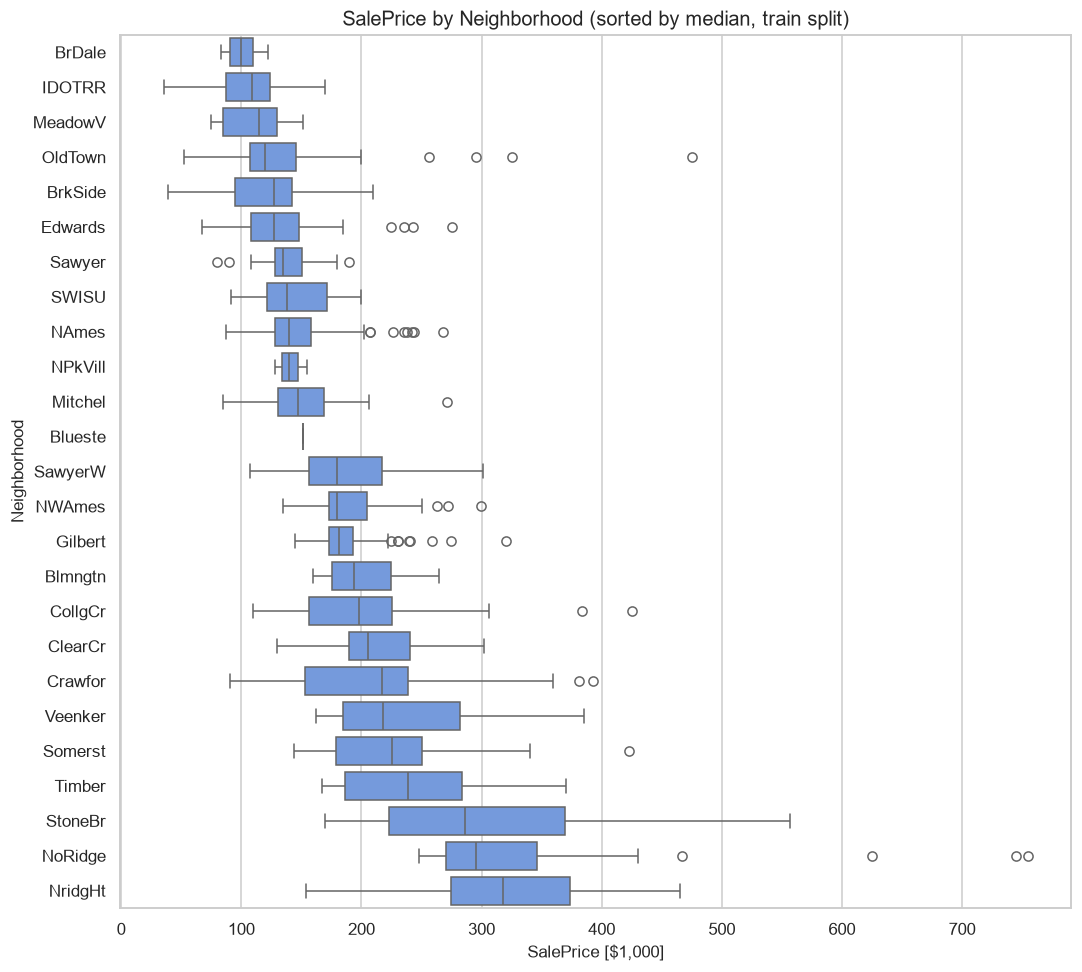

In [10]:
"""Neighborhood price ranking — figure 09."""
nb = train.groupby("Neighborhood").agg(
    n=("SalePrice", "size"),
    median_price=("SalePrice", "median"),
    mean_price=("SalePrice", "mean"),
    median_ppsqft=("price_per_sqft", "median"),
).sort_values("median_price", ascending=False)
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")
print(nb.to_string())
pd.reset_option("display.float_format")

top, bottom = nb["median_price"].iloc[0], nb["median_price"].iloc[-1]
print(f"\nspread: {nb.index[0]} ${top:,.0f} vs {nb.index[-1]} ${bottom:,.0f} "
      f"-> ratio {top / bottom:.2f}x, gap ${top - bottom:,.0f}")

order = nb.index[::-1]  # ascending for horizontal plot
fig, ax = plt.subplots(figsize=(10, 9))
sns.boxplot(data=train, y="Neighborhood", x=train["SalePrice"] / 1000, order=order, ax=ax, color="cornflowerblue")
ax.set(title="SalePrice by Neighborhood (sorted by median, train split)",
       xlabel="SalePrice [$1,000]", ylabel="Neighborhood")
fig.tight_layout()
save_fig(fig, "09_neighborhood_prices.png")
plt.show()


**Interpretation.** Neighborhood medians span a **3.18× range** — from
Briardale ($100k), Iowa DOT & Rail Road ($109k) and Meadow Village ($115k) at
the bottom to Northridge Heights ($318k), Northridge ($296k) and Stone Brook
($286k) at the top. Some cheap neighborhoods are *small-home* neighborhoods
rather than low-$/sqft ones (Meadow Village: low median price but median
$/sqft near the city average; SWISU is the opposite extreme — decent prices on
the lowest $/sqft). With only 25 categories and a strong spread, neighborhood
is a high-value categorical; several areas have few sales (Blueste n=1,
NPkVill n=3, MeadowV n=9) so their medians are noisy — a caution for the
train-only neighborhood stats join (SPEC §5): shrinkage/noise on rare
neighborhoods.


## 10. Days on market and the fast-sale target

> **SIMULATED TARGET (ADR-3).** Ames has no real days-on-market field.
> `days_on_market` and `sells_within_30_days` are produced by the transparent,
> seeded simulation in `ml/data/sale_speed.py` from real features (pricing vs
> neighborhood median, condition, seasonality, market velocity). Distributions
> below describe that simulation — classification metrics are **not**
> real-world performance claims.


days_on_market [SIMULATED]:
  min 8, 25% 30, median 41, 75% 54, max 141
  mean 44.2, std 19.0, skew 1.26

sells_within_30_days class balance: fast=239 (25.3%), slow=706 (74.7%)
median DOM | fast-sale: 25 d | slow-sale: 47 d


saved -> figures\10_days_on_market.png


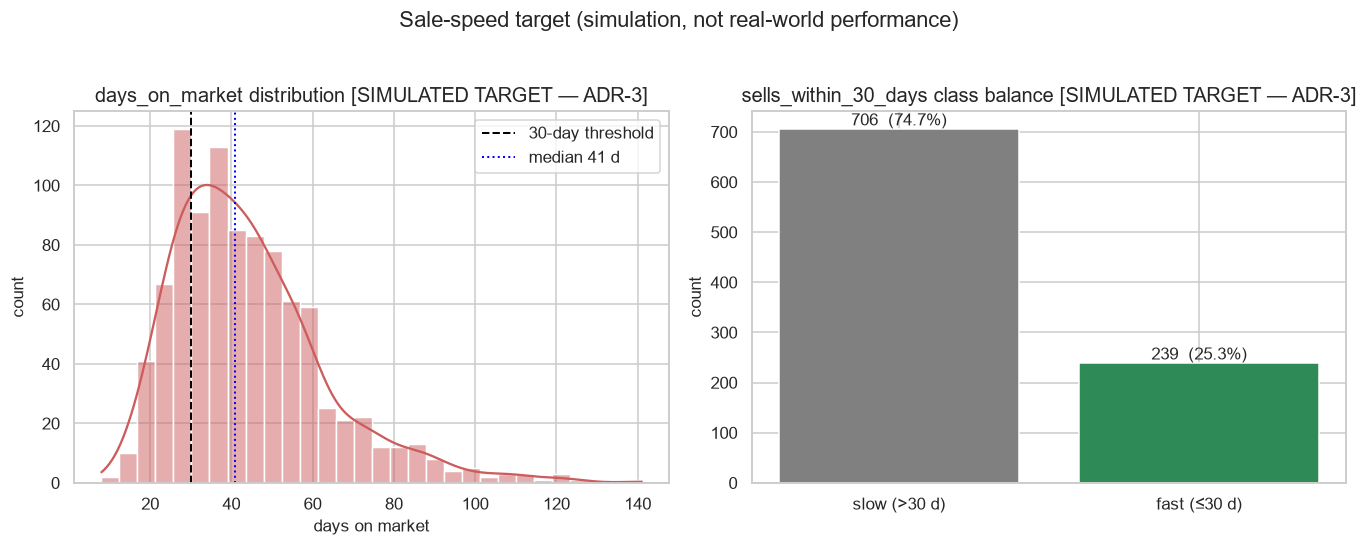

In [11]:
"""days_on_market + sells_within_30_days distributions — figure 10 (SIMULATED target, ADR-3)."""
dom = train["days_on_market"]
fast = train["sells_within_30_days"]
print("days_on_market [SIMULATED]:")
print(f"  min {dom.min()}, 25% {dom.quantile(0.25):.0f}, median {dom.median():.0f}, "
      f"75% {dom.quantile(0.75):.0f}, max {dom.max()}")
print(f"  mean {dom.mean():.1f}, std {dom.std():.1f}, skew {dom.skew():.2f}")
n_fast = int(fast.sum())
print(f"\nsells_within_30_days class balance: fast={n_fast} ({fast.mean() * 100:.1f}%), "
      f"slow={len(fast) - n_fast} ({(1 - fast.mean()) * 100:.1f}%)")
print(f"median DOM | fast-sale: {dom[fast == 1].median():.0f} d | slow-sale: {dom[fast == 0].median():.0f} d")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
sns.histplot(dom, bins=30, kde=True, ax=axes[0], color="indianred")
axes[0].axvline(30, color="black", ls="--", lw=1.3, label="30-day threshold")
axes[0].axvline(dom.median(), color="blue", ls=":", lw=1.3, label=f"median {dom.median():.0f} d")
axes[0].set(title="days_on_market distribution [SIMULATED TARGET — ADR-3]",
            xlabel="days on market", ylabel="count")
axes[0].legend()
bars = axes[1].bar(["slow (>30 d)", "fast (≤30 d)"], [len(fast) - n_fast, n_fast],
                   color=["gray", "seagreen"])
for b, v in zip(bars, [len(fast) - n_fast, n_fast]):
    axes[1].annotate(f"{v}  ({v / len(fast) * 100:.1f}%)", (b.get_x() + b.get_width() / 2, b.get_height()),
                     ha="center", va="bottom", fontsize=11)
axes[1].set(title="sells_within_30_days class balance [SIMULATED TARGET — ADR-3]", ylabel="count")
fig.suptitle("Sale-speed target (simulation, not real-world performance)", y=1.03)
fig.tight_layout()
save_fig(fig, "10_days_on_market.png")
plt.show()


**Interpretation.** The simulated DOM is right-skewed with most sales in the
~30–55 day band and a tail past 90 days. The fast-sale class is ≈ 25% of train
— a moderately imbalanced binary target. Classifiers must therefore use
class-imbalance-aware training (class weights / PR-AUC as primary metric, per
SPEC §6 champion rule) rather than accuracy. Because the target is simulated,
these numbers validate the pipeline, not market realism.


## 11. Correlation structure of key numerics

Pearson heatmap over the main numeric features (incl. the EDA-only derived
ones) plus Spearman ranking against the target.


saved -> figures\11_correlation_heatmap.png


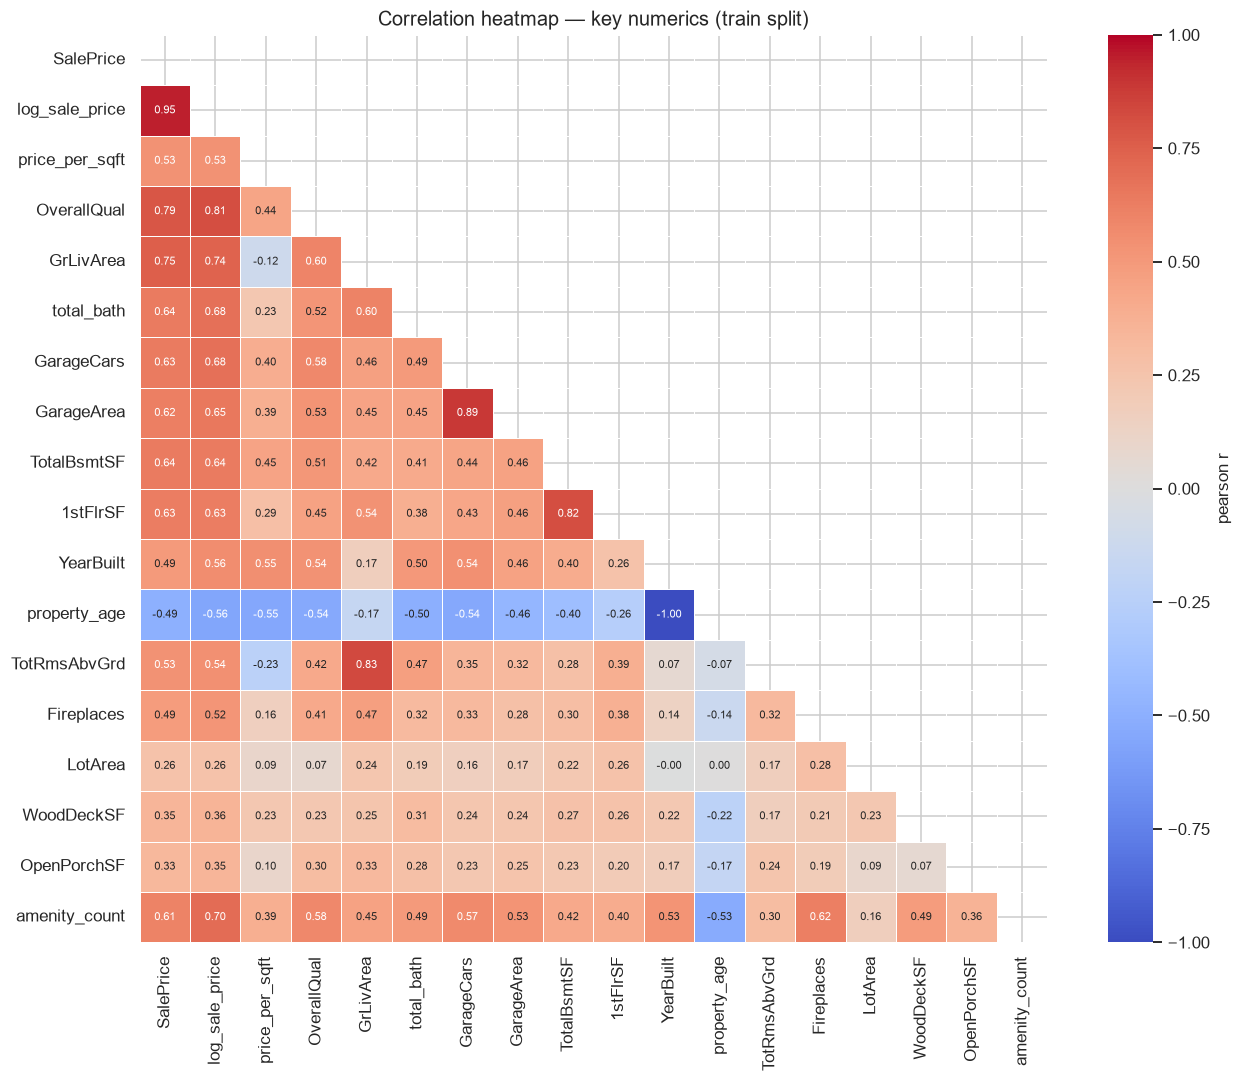


Top numeric correlations with SalePrice (target-derived cols excluded):
               pearson  spearman
OverallQual      0.789     0.795
GrLivArea        0.752     0.751
TotalBsmtSF      0.639     0.589
total_bath       0.636     0.707
GarageCars       0.634     0.695
1stFlrSF         0.632     0.584
GarageArea       0.618     0.644
amenity_count    0.609     0.714
TotRmsAbvGrd     0.534     0.540
YearBuilt        0.493     0.622


In [12]:
"""Correlation heatmap of key numerics vs SalePrice — figure 11."""
CORR_COLS = [
    "SalePrice", "log_sale_price", "price_per_sqft", "OverallQual", "GrLivArea",
    "total_bath", "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF",
    "YearBuilt", "property_age", "TotRmsAbvGrd", "Fireplaces", "LotArea",
    "WoodDeckSF", "OpenPorchSF", "amenity_count",
]
corr = train[CORR_COLS].corr(method="pearson")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12.5, 10))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7.5}, square=True,
            linewidths=0.4, cbar_kws={"label": "pearson r"}, ax=ax)
ax.set_title("Correlation heatmap — key numerics (train split)")
fig.tight_layout()
save_fig(fig, "11_correlation_heatmap.png")
plt.show()

target_corr = (
    train[CORR_COLS].drop(columns=["SalePrice", "log_sale_price", "price_per_sqft"])
    .corrwith(train["SalePrice"], method="pearson")
    .rename("pearson")
    .to_frame()
)
target_corr["spearman"] = train[CORR_COLS].drop(
    columns=["SalePrice", "log_sale_price", "price_per_sqft"]
).corrwith(train["SalePrice"], method="spearman")
target_corr = target_corr.reindex(target_corr["pearson"].abs().sort_values(ascending=False).index)
print("\nTop numeric correlations with SalePrice (target-derived cols excluded):")
print(target_corr.round(3).head(10).to_string())


**Interpretation.** The target's strongest numeric friends are `OverallQual`,
size (`GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `GarageArea/Cars`, `total_bath`)
and `YearBuilt`. Heavy multicollinearity sits inside the size block
(`GrLivArea`≈`TotRmsAbvGrd`, `GarageCars`≈`GarageArea`, `1stFlrSF`≈`TotalBsmtSF`)
— tree ensembles absorb it; **linear models need regularization** (ridge/lasso,
which are in the model plan) and their coefficients should not be read as
causal. `log_sale_price` correlates more uniformly with drivers than raw price,
again backing ADR-10. `LotArea` and porch/deck areas are weak individually.


## 12. Missingness profile — RAW Ames data

The **processed** split has zero NaNs by construction (SPEC §14: absent features
→ literal `"None"`/0). The interesting missingness lives in the **raw**
`data/raw/ames/train.csv` (1460 rows, read with default NA parsing here).
Per `data_description.txt`, most "missing" values are **structural**: NA means
"feature absent" (no pool, no alley, no garage…), not unknown.


raw train: 1460 rows x 81 cols; 19 columns with missing values
              n_missing   pct
PoolQC             1453  99.5
MiscFeature        1406  96.3
Alley              1369  93.8
Fence              1179  80.8
MasVnrType          872  59.7
FireplaceQu         690  47.3
LotFrontage         259  17.7
GarageType           81   5.5
GarageYrBlt          81   5.5
GarageFinish         81   5.5
GarageQual           81   5.5
GarageCond           81   5.5
BsmtExposure         38   2.6
BsmtFinType2         38   2.6
BsmtQual             37   2.5
BsmtCond             37   2.5
BsmtFinType1         37   2.5
MasVnrArea            8   0.5
Electrical            1   0.1


saved -> figures\12_missingness_raw.png


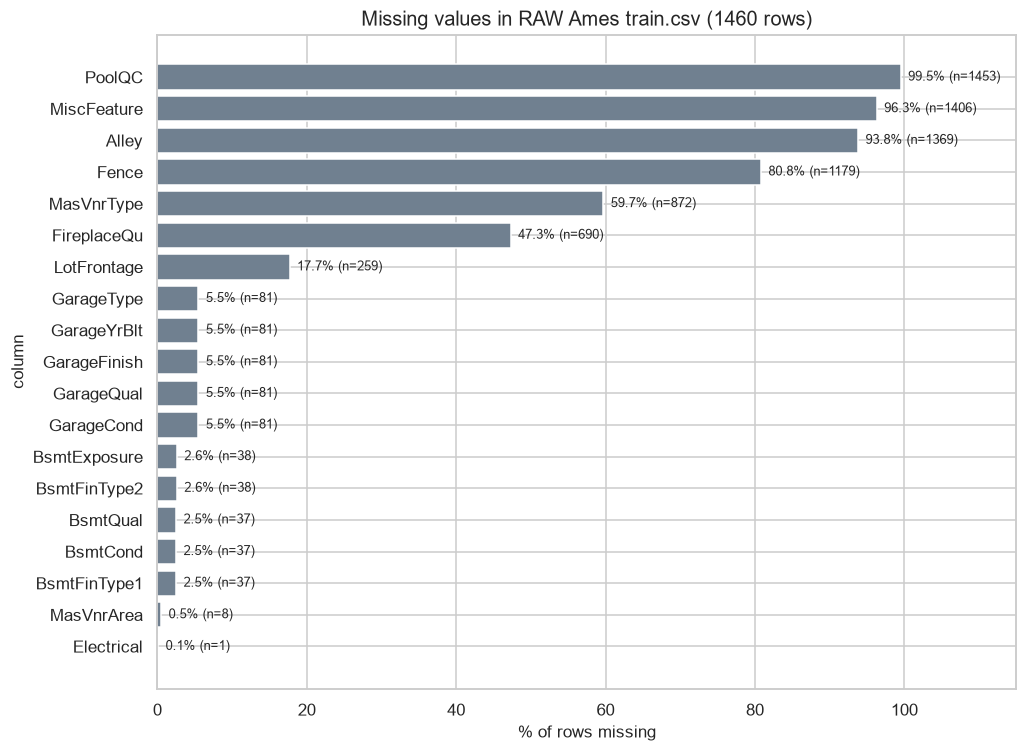

In [13]:
"""Missingness in the raw Ames train.csv — figure 12."""
raw = pd.read_csv(RAW_AMES_DIR / "train.csv")  # default NA parsing: raw has real NaNs
miss = raw.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(raw) * 100).round(1)
miss_tbl = pd.DataFrame({"n_missing": miss, "pct": miss_pct})
print(f"raw train: {raw.shape[0]} rows x {raw.shape[1]} cols; "
      f"{len(miss)} columns with missing values")
print(miss_tbl.to_string())

fig, ax = plt.subplots(figsize=(9.5, 7))
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1], color="slategray")
for i, (v, n) in enumerate(zip(miss_pct.values[::-1], miss.values[::-1])):
    ax.text(v + 1, i, f"{v}% (n={n})", va="center", fontsize=8.5)
ax.set(title="Missing values in RAW Ames train.csv (1460 rows)",
       xlabel="% of rows missing", ylabel="column")
ax.set_xlim(0, 115)
fig.tight_layout()
save_fig(fig, "12_missingness_raw.png")
plt.show()


**Interpretation.** The worst columns (`PoolQC` 99.5%, `MiscFeature` 96.3%,
`Alley` 93.8%, `Fence` 80.8%, `MasVnrType` 59.7%, `FireplaceQu` 47.3%) are
"missing" purely because most homes lack the feature — filling them with
`"None"` (as the pipeline does) is semantically correct, not imputation. The
garage block (5 columns, all 5.5%, same 81 rows) and basement block (~2.5%)
follow the same absent-feature logic. Only `LotFrontage` (17.7%) is a genuine
measurement gap — hence the documented median-within-neighborhood imputation
fit **on train only** (SPEC §4) — while `MasVnrArea` (0.5%) and `Electrical`
(1 row) are negligible. Takeaway for modeling: "None" is a legitimate
category, and absence itself (e.g. has-pool) carries signal already captured
by `amenity_count`.


## 13. Outlier analysis

Reference: `data/processed/outliers_report.json`. The pipeline removed exactly
**2 rows on the train split** (Ids 524, 1299): the documented Ames caveat —
`GrLivArea > 4000` sqft *partial sales* whose prices are not market-comparable
(SPEC §4 allows rule-based trimming on train only, with justification).
Everything else is **kept** — this section checks whether that is defensible.


outliers_report.json:
{
  "partial_sale_grlivarea_gt_4000": {
    "removed_ids": [
      524,
      1299
    ],
    "n_removed": 2,
    "justification": "Known Ames caveat: ``GrLivArea > 4000`` sqft with a low price."
  },
  "summary": {
    "rows_before": 947,
    "rows_after": 945,
    "applied_to": "train split only"
  }
}

removed rows (raw, YrSold<=2008 population, n=947):
  Id  GrLivArea  SalePrice SaleCondition Neighborhood
 524       4676     184750       Partial      Edwards
1299       5642     160000       Partial      Edwards

SalePrice IQR fence: Q1=$130,500, Q3=$215,000, upper=$341,750; 39 train rows above (4.1%)
GrLivArea IQR upper fence: 2,794 sqft; 18 rows above; max GrLivArea now 4,476 sqft


saved -> figures\13_outliers.png


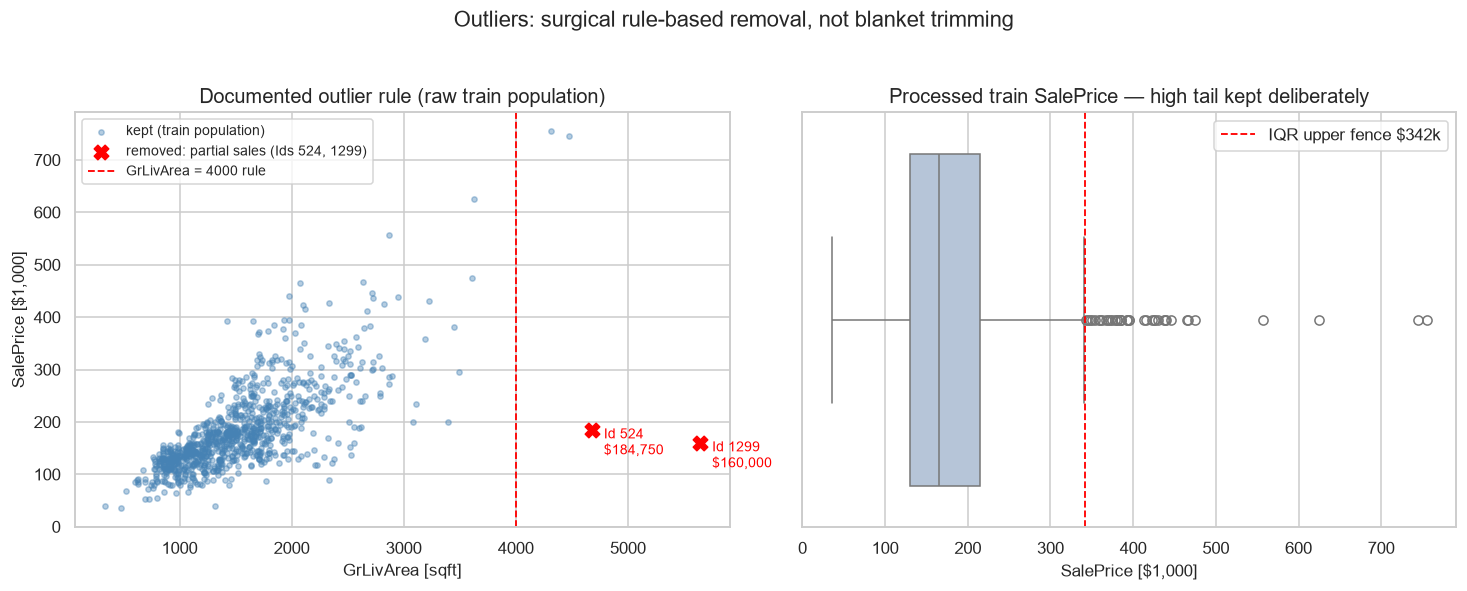

In [14]:
"""Outlier view: the 2 documented removals in context + IQR profile — figure 13."""
report = json.loads((PROCESSED_DIR / "outliers_report.json").read_text())
print("outliers_report.json:")
print(json.dumps(report, indent=2))

removed_ids = report["partial_sale_grlivarea_gt_4000"]["removed_ids"]
raw_train_split = raw[raw["YrSold"] <= 2008].copy()  # population the rules were applied to
removed = raw_train_split[raw_train_split["Id"].isin(removed_ids)]
print(f"\nremoved rows (raw, YrSold<=2008 population, n={len(raw_train_split)}):")
print(removed[["Id", "GrLivArea", "SalePrice", "SaleCondition", "Neighborhood"]].to_string(index=False))

q1, q3 = train["SalePrice"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
n_hi = int((train["SalePrice"] > upper).sum())
print(f"\nSalePrice IQR fence: Q1=${q1:,.0f}, Q3=${q3:,.0f}, upper=${upper:,.0f}; "
      f"{n_hi} train rows above ({n_hi / len(train) * 100:.1f}%)")
g_q1, g_q3 = train["GrLivArea"].quantile([0.25, 0.75])
g_upper = g_q3 + 1.5 * (g_q3 - g_q1)
print(f"GrLivArea IQR upper fence: {g_upper:,.0f} sqft; "
      f"{int((train['GrLivArea'] > g_upper).sum())} rows above; "
      f"max GrLivArea now {train['GrLivArea'].max():,.0f} sqft")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
kept = raw_train_split[~raw_train_split["Id"].isin(removed_ids)]
axes[0].scatter(kept["GrLivArea"], kept["SalePrice"] / 1000, s=12, alpha=0.4,
                color="steelblue", label="kept (train population)")
axes[0].scatter(removed["GrLivArea"], removed["SalePrice"] / 1000, s=90, marker="X",
                color="red", zorder=5, label="removed: partial sales (Ids 524, 1299)")
for _, r in removed.iterrows():
    axes[0].annotate(f"Id {int(r['Id'])}\n${r['SalePrice']:,}", (r["GrLivArea"], r["SalePrice"] / 1000),
                     textcoords="offset points", xytext=(8, -16), fontsize=9, color="red")
axes[0].axvline(4000, color="red", ls="--", lw=1.2, label="GrLivArea = 4000 rule")
axes[0].set(title="Documented outlier rule (raw train population)", xlabel="GrLivArea [sqft]",
            ylabel="SalePrice [$1,000]")
axes[0].legend(loc="upper left", fontsize=9)
sns.boxplot(x=train["SalePrice"] / 1000, ax=axes[1], color="lightsteelblue")
axes[1].axvline(upper / 1000, color="red", ls="--", lw=1.2, label=f"IQR upper fence ${upper / 1000:,.0f}k")
axes[1].set(title="Processed train SalePrice — high tail kept deliberately", xlabel="SalePrice [$1,000]")
axes[1].legend()
fig.suptitle("Outliers: surgical rule-based removal, not blanket trimming", y=1.03)
fig.tight_layout()
save_fig(fig, "13_outliers.png")
plt.show()


**Interpretation.** The two removed rows are enormous (>4000 sqft) yet sold far
*below* what their size predicts — both are `Partial` sale conditions (homes
sold incomplete / family transfers), i.e. measurement artifacts, not market
signal; deleting them is correct and SPEC-compliant. The remaining high-price
tail (39 rows, ≈4% of train, above the $341,750 IQR fence) is **real luxury
stock** concentrated in
premium neighborhoods — removing it would bias the model exactly where
valuation matters most, so it stays. Justification for *not* trimming further:
(1) log1p target already compresses the tail; (2) tree models are robust to
monotone tail points; (3) the high-end rows are consistent with their
neighborhood/quality context, unlike the two partial sales.


## 14. Seasonality — `MoSold` / `YrSold`

Train covers sales from 2006–2008 (YrSold ≤ 2008); `val.csv` (2009) is included
**only** in the yearly panel to show the trend continues into the validation
year. Test (2010) remains sealed.


Train sales by MoSold:
        n_sales  median_price
MoSold                       
1            35      149000.0
2            27      173000.0
3            66      160000.0
4            76      141000.0
5           119      158000.0
6           158      159475.0
7           167      170000.0
8            92      175742.0
9            43      191000.0
10           61      159000.0
11           57      184000.0
12           44      180500.0

peak month: 7 (167 sales) | slowest: 2 (27 sales)

Yearly view (train 2006–2008 + val 2009):
        n_sales  median_price
YrSold                       
2006        314      163995.0
2007        328      166000.0
2008        303      165000.0
2009        338      162000.0
median price 2006 -> 2008: $163,995 -> $165,000 (+0.6%)


saved -> figures\14_seasonality.png


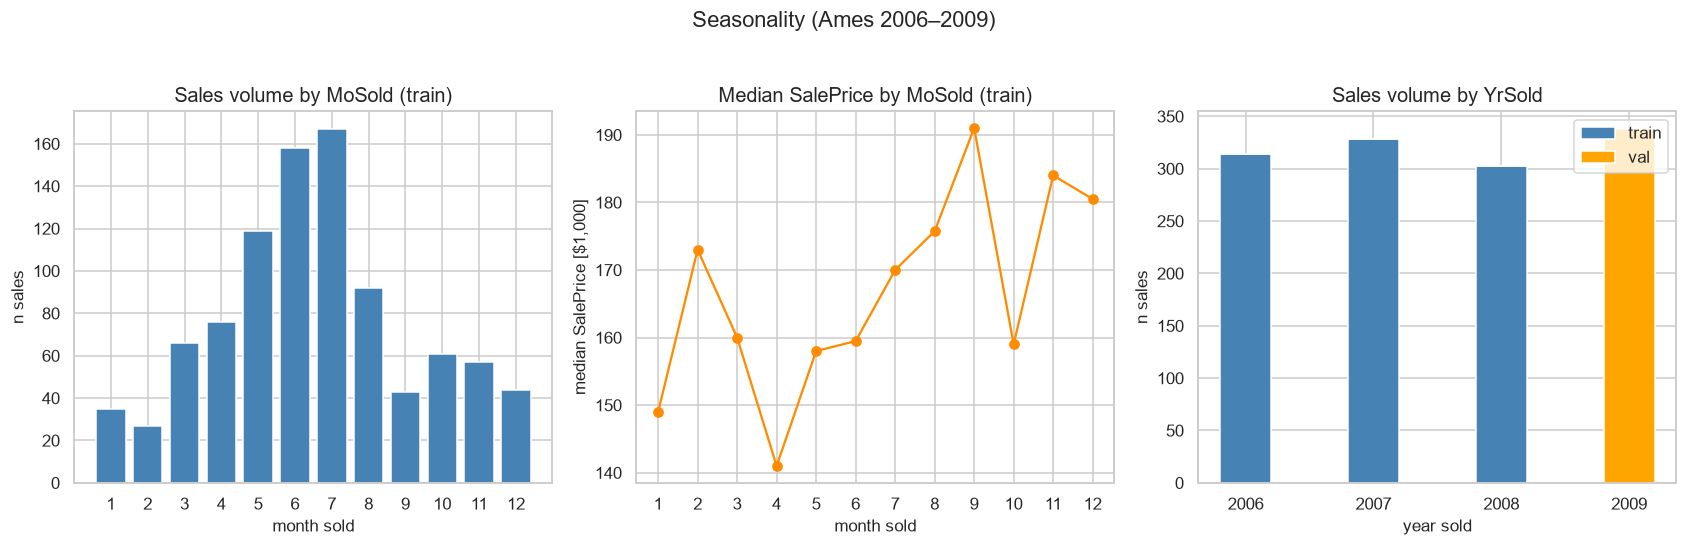

In [15]:
"""Seasonality by month and year — figure 14."""
val = pd.read_csv(PROCESSED_DIR / "val.csv", keep_default_na=False)

mo_counts = train.groupby("MoSold")["SalePrice"].size()
mo_median = train.groupby("MoSold")["SalePrice"].median()
peak_mo, low_mo = int(mo_counts.idxmax()), int(mo_counts.idxmin())
print("Train sales by MoSold:")
print(pd.DataFrame({"n_sales": mo_counts, "median_price": mo_median.round(0)}).to_string())
print(f"\npeak month: {peak_mo} ({mo_counts.max()} sales) | slowest: {low_mo} ({mo_counts.min()} sales)")

yr_counts = pd.concat([train.groupby("YrSold").size(), val.groupby("YrSold").size()])
yr_median = pd.concat([train.groupby("YrSold")["SalePrice"].median(),
                       val.groupby("YrSold")["SalePrice"].median()])
print("\nYearly view (train 2006–2008 + val 2009):")
print(pd.DataFrame({"n_sales": yr_counts, "median_price": yr_median.round(0)}).to_string())
med06, med08 = yr_median.loc[2006], yr_median.loc[2008]
print(f"median price 2006 -> 2008: ${med06:,.0f} -> ${med08:,.0f} ({(med08 / med06 - 1) * 100:+.1f}%)")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
axes[0].bar(mo_counts.index.astype(str), mo_counts.values, color="steelblue")
axes[0].set(title="Sales volume by MoSold (train)", xlabel="month sold", ylabel="n sales")
axes[1].plot(mo_median.index, mo_median.values / 1000, marker="o", color="darkorange")
axes[1].set(title="Median SalePrice by MoSold (train)", xlabel="month sold", ylabel="median SalePrice [$1,000]")
axes[1].set_xticks(range(1, 13))
width = 0.4
years = sorted(set(train["YrSold"]) | set(val["YrSold"]))
tr_c = [int((train["YrSold"] == y).sum()) for y in years]
va_c = [int((val["YrSold"] == y).sum()) for y in years]
axes[2].bar([str(y) for y in years], tr_c, width, label="train", color="steelblue")
axes[2].bar([str(y) for y in years], va_c, width, bottom=tr_c, label="val", color="orange")
axes[2].set(title="Sales volume by YrSold", xlabel="year sold", ylabel="n sales")
axes[2].legend()
fig.suptitle("Seasonality (Ames 2006–2009)", y=1.03)
fig.tight_layout()
save_fig(fig, "14_seasonality.png")
plt.show()


**Interpretation.** Volume is strongly seasonal — the classic spring/early-summer
peak (May–July) and a winter trough (Dec–Feb) — while the *median price* by
month moves much less: seasonality is mostly about **transaction volume**, not
price level. Year over year, medians are nearly flat into 2008 with volume
holding up (the Ames market was comparatively insulated from the 2008 crash).
Consequences: (1) `sale_month`/`sale_quarter` are reasonable weak features but
should not be expected to carry much price signal; (2) the time-based split
(ADR-4) is sound — no dramatic regime break between train (≤2008) and val
(2009) is visible, though volume mix differs by construction of the split.


## 15. Key numbers & implications for modeling


In [16]:
"""Consolidated key numbers (used verbatim in reports/EDA_REPORT.md)."""
print("=== KEY NUMBERS (train split, n=%d) ===" % len(train))
print(f"SalePrice: mean ${sp.mean():,.0f} | median ${sp.median():,.0f} | std ${sp.std():,.0f} | "
      f"range ${sp.min():,}–${sp.max():,}")
print(f"skew: raw {sp.skew():.3f} -> log1p {np.log1p(sp).skew():.3f}")
print(f"price_per_sqft: median ${pps.median():,.2f} | mean ${pps.mean():,.2f} | skew {pps.skew():.3f}")
print("top pearson |r| vs SalePrice:")
for name, row in target_corr.head(6).iterrows():
    print(f"  {name:<12} pearson {row['pearson']:+.3f} | spearman {row['spearman']:+.3f}")
print(f"neighborhood median spread: {nb.index[0]} ${top:,.0f} vs {nb.index[-1]} ${bottom:,.0f} "
      f"({top / bottom:.2f}x)")
print(f"fast-sale class balance: {fast.mean() * 100:.1f}% fast / {(1 - fast.mean()) * 100:.1f}% slow "
      f"[SIMULATED TARGET — ADR-3]")
print(f"days_on_market: median {dom.median():.0f} d, IQR {dom.quantile(0.25):.0f}–{dom.quantile(0.75):.0f} d, "
      f"max {dom.max()} d [SIMULATED]")
print(f"outliers removed on train: {report['partial_sale_grlivarea_gt_4000']['n_removed']} partial-sale rows "
      f"(Ids {removed_ids}); {n_hi} high-price rows above IQR fence kept deliberately")
print(f"raw missingness: {len(miss)} cols; worst {miss_pct.index[0]} {miss_pct.iloc[0]}% "
      f"(structural NA = absent feature)")
print(f"seasonality: peak MoSold={peak_mo} ({mo_counts.max()} sales), trough MoSold={low_mo} "
      f"({mo_counts.min()} sales); median price 2006->2008 {(med08 / med06 - 1) * 100:+.1f}%")


=== KEY NUMBERS (train split, n=945) ===
SalePrice: mean $182,125 | median $164,990 | std $78,872 | range $35,311–$755,000
skew: raw 1.967 -> log1p 0.175
price_per_sqft: median $120.58 | mean $121.13 | skew 0.434
top pearson |r| vs SalePrice:
  OverallQual  pearson +0.789 | spearman +0.795
  GrLivArea    pearson +0.752 | spearman +0.751
  TotalBsmtSF  pearson +0.639 | spearman +0.589
  total_bath   pearson +0.636 | spearman +0.707
  GarageCars   pearson +0.634 | spearman +0.695
  1stFlrSF     pearson +0.632 | spearman +0.584
neighborhood median spread: NridgHt $318,000 vs BrDale $100,000 (3.18x)
fast-sale class balance: 25.3% fast / 74.7% slow [SIMULATED TARGET — ADR-3]
days_on_market: median 41 d, IQR 30–54 d, max 141 d [SIMULATED]
outliers removed on train: 2 partial-sale rows (Ids [524, 1299]); 39 high-price rows above IQR fence kept deliberately
raw missingness: 19 cols; worst PoolQC 99.5% (structural NA = absent feature)
seasonality: peak MoSold=7 (167 sales), trough MoSold=2 (27 

### Implications for modeling

1. **Log target (ADR-10) is mandatory, not optional.** Raw-price skew ≈ 1.9 with
   variance growing in size; `log1p` brings skew to ≈ 0.1. Train on
   `log1p(SalePrice)`, report dollar metrics via `expm1`, RMSLE primary.
2. **Tree ensembles should beat plain linear models** out of the box:
   non-linear size effects, non-monotone age/condition curves, and interactions
   (quality × neighborhood). A linear baseline is still useful (interpretable
   benchmark) but needs the log target, regularization (ridge/lasso for the
   collinear size block) and ideally binned age / transformed LotArea to compete.
3. **Feature expectations.** `OverallQual` will dominate importance, followed by
   the size block (`GrLivArea`/`TotalBsmtSF`/`Garage*`, `total_bath`), then
   neighborhood and age. Heavy multicollinearity inside the size block means
   importance is *split* across near-duplicates — read SHAP groups, not single
   ranks; do not interpret linear coefficients causally.
4. **Leakage cautions (hard rules, SPEC §5).** `price_per_sqft` and anything
   `SalePrice`-derived per-row is EDA/clustering-only. Neighborhood statistics
   must be fit on train only and re-joined to val/test (rare neighborhoods have
   noisy medians — expect some shrinkage issues). `days_on_market` /
   `sells_within_30_days` are **targets**, never features. `SaleType`/
   `SaleCondition` are post-hoc (they would have flagged the two partial-sale
   outliers!) and stay excluded.
5. **Classification target is simulated (ADR-3).** ≈ 25% fast-sale rate →
   class-weight-aware training, PR-AUC primary + Brier calibration check; all
   reported metrics must carry the simulated-target label.
6. **Preprocessing.** "None" is a real category, not missing → OneHot with
   `handle_unknown='ignore'`; only `LotFrontage` needs true imputation
   (train-fit neighborhood medians). No blanket outlier removal: the 2 partial
   sales are already trimmed; the luxury tail is genuine signal.
7. **Clustering (ADR-9).** Location value lives in neighborhood identity rather
   than radial distance; neighborhood-level median $/sqft + velocity + coords is
   the right grain for micro-market discovery.
